### Telco Customer Churn Prediction

In this project, I try to predict whether a telecom customer will churn or not.

If a company can identify customers who are likely to leave, it can offer
discounts or retention offers to keep those customers.

Instead of focusing only on model accuracy, this project also considers
business cost.

### Dataset

This dataset contains telecom customer information such as:

- tenure
- monthly charges
- contract type
- payment method
- internet service

The goal is to predict whether the customer will churn or stay.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel("Telco_customer_churn.xlsx")

# Remove leakage columns and useless columns
df = df.drop(["CustomerID","Count","Churn Value","Churn Score","Churn Reason"], axis=1)

# Remove unnecessary geographic columns
df = df.drop(["Country","State","City","Lat Long"], axis=1)

# Convert target variable
df["Churn Label"] = df["Churn Label"].map({"Yes":1,"No":0})

df.head()

,Zip Code,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,...,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,CLTV
0,90003,33.964131,-118.272783,Male,No,No,No,2,Yes,No,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,3239
1,90005,34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,2701
2,90006,34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,1,5372
3,90010,34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,...,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1,5003
4,90015,34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,...,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,1,5340


### Dataset

The dataset contains telecom customer information including demographics, service usage, billing information, and churn status.

Important features include:

• Tenure Months – how long the customer has stayed  
• Monthly Charges – monthly subscription cost  
• Total Charges – total money paid by the customer  
• Contract Type – month-to-month or long-term contract  
• Payment Method – how the customer pays the bill  

The target variable is **Churn Label**, which indicates whether the customer left the service.

In [3]:
df.shape

(7043, 24)

### Dataset Size

This step checks the number of rows and columns in the dataset.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Zip Code           7043 non-null   int64  
 1   Latitude           7043 non-null   float64
 2   Longitude          7043 non-null   float64
 3   Gender             7043 non-null   object 
 4   Senior Citizen     7043 non-null   object 
 5   Partner            7043 non-null   object 
 6   Dependents         7043 non-null   object 
 7   Tenure Months      7043 non-null   int64  
 8   Phone Service      7043 non-null   object 
 9   Multiple Lines     7043 non-null   object 
 10  Internet Service   7043 non-null   object 
 11  Online Security    7043 non-null   object 
 12  Online Backup      7043 non-null   object 
 13  Device Protection  7043 non-null   object 
 14  Tech Support       7043 non-null   object 
 15  Streaming TV       7043 non-null   object 
 16  Streaming Movies   7043 

### Data Types

We inspect the data types of each column to understand which variables are numerical and which are categorical.

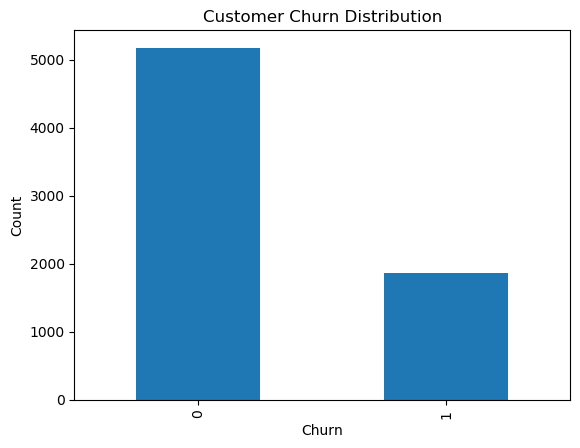

In [5]:
df['Churn Label'].value_counts().plot(kind='bar')
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

### Churn Distribution

This visualization shows that the dataset is imbalanced.
More customers stayed compared to those who churned.

Therefore accuracy alone may not be the best metric.

In [6]:
df.dtypes

Zip Code               int64
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges         object
Churn Label            int64
CLTV                   int64
dtype: object

In [7]:
df.select_dtypes(include="object").columns

Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Total Charges'],
      dtype='object')

In [8]:
len(df.select_dtypes(include="object").columns)

17

In [9]:
df.columns

Index(['Zip Code', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'CLTV'],
      dtype='object')

In [10]:
df["Churn Label"].value_counts()


0    5174
1    1869
Name: Churn Label, dtype: int64

In [11]:
df.isnull().sum()


Zip Code             0
Latitude             0
Longitude            0
Gender               0
Senior Citizen       0
Partner              0
Dependents           0
Tenure Months        0
Phone Service        0
Multiple Lines       0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Streaming TV         0
Streaming Movies     0
Contract             0
Paperless Billing    0
Payment Method       0
Monthly Charges      0
Total Charges        0
Churn Label          0
CLTV                 0
dtype: int64

### Missing Value Analysis

We check for missing values in the dataset to ensure data quality before training machine learning models.

In [12]:
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")

In [13]:
df["Total Charges"].isnull().sum()

11

In [14]:
df = df.dropna(subset=["Total Charges"])

In [15]:
df.isnull().sum()


Zip Code             0
Latitude             0
Longitude            0
Gender               0
Senior Citizen       0
Partner              0
Dependents           0
Tenure Months        0
Phone Service        0
Multiple Lines       0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Streaming TV         0
Streaming Movies     0
Contract             0
Paperless Billing    0
Payment Method       0
Monthly Charges      0
Total Charges        0
Churn Label          0
CLTV                 0
dtype: int64

In [16]:
y = df["Churn Label"]
X = df.drop("Churn Label", axis=1)

In [17]:
print(X.shape)
print(y.shape)

(7032, 23)
(7032,)


## Train-Test Split

To evaluate the machine learning model properly, the dataset is split into
training and testing sets.

- Training data is used to train the model.
- Testing data is used to evaluate model performance.

We use an 80/20 split and apply stratification to preserve the churn distribution.

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [19]:
print(type(X_train))

<class 'pandas.core.frame.DataFrame'>


### Feature Encoding

Machine learning models cannot work with categorical variables directly.
Therefore, categorical features are converted into numerical format using
one-hot encoding.

The parameter `drop_first=True` is used to avoid the dummy variable trap
and reduce multicollinearity.

In [20]:
# Encode categorical variables
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# Make sure both train and test have same columns
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [21]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=1000,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=None, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

### Logistic Regression Model

Logistic Regression is used as a baseline machine learning model for churn prediction.

In [22]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[924 109]
 [207 167]]
              precision    recall  f1-score   support

           0       0.82      0.89      0.85      1033
           1       0.61      0.45      0.51       374

    accuracy                           0.78      1407
   macro avg       0.71      0.67      0.68      1407
weighted avg       0.76      0.78      0.76      1407



In [23]:
import pandas as pd

coefficients = pd.Series(model.coef_[0], index=X_train.columns)
coefficients.sort_values(ascending=False).head(10)

Monthly Charges                    0.041624
Internet Service_Fiber optic       0.000808
Payment Method_Electronic check    0.000599
Paperless Billing_Yes              0.000467
Streaming TV_Yes                   0.000364
Streaming Movies_Yes               0.000352
Multiple Lines_Yes                 0.000297
Senior Citizen_Yes                 0.000272
Longitude                          0.000114
Device Protection_Yes              0.000081
dtype: float64

In [24]:
coefficients.sort_values().head(10)

Tenure Months                           -0.018814
Online Security_No internet service     -0.000535
Streaming Movies_No internet service    -0.000535
Streaming TV_No internet service        -0.000535
Tech Support_No internet service        -0.000535
Device Protection_No internet service   -0.000535
Online Backup_No internet service       -0.000535
Internet Service_No                     -0.000535
Dependents_Yes                          -0.000454
Contract_Two year                       -0.000420
dtype: float64

In [25]:
df = df.drop(["Churn Value","Churn Score","Churn Reason"], axis=1, errors="ignore")

In [26]:
y = df["Churn Label"]
X = df.drop("Churn Label", axis=1)

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [28]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [29]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=1000,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=None, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

In [30]:
y_pred = model.predict(X_test)

In [31]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_pred))

[[924 109]
 [207 167]]


In [32]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.89      0.85      1033
           1       0.61      0.45      0.51       374

    accuracy                           0.78      1407
   macro avg       0.71      0.67      0.68      1407
weighted avg       0.76      0.78      0.76      1407



In [33]:
from sklearn.linear_model import LogisticRegression

model_balanced = LogisticRegression(max_iter=1000, class_weight='balanced')
model_balanced.fit(X_train, y_train)

y_pred_balanced = model_balanced.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1033
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.80      0.74      0.75      1407



In [34]:
import pandas as pd

coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model_balanced.coef_[0]
})

coefficients = coefficients.sort_values(by="Coefficient", ascending=False)

print(coefficients.head(10))
print(coefficients.tail(10))

                            Feature  Coefficient
32  Payment Method_Electronic check     0.542738
30            Paperless Billing_Yes     0.380167
8                Senior Citizen_Yes     0.312896
14     Internet Service_Fiber optic     0.271384
12  Multiple Lines_No phone service     0.260382
13               Multiple Lines_Yes     0.132392
2                         Longitude     0.087746
1                          Latitude     0.068223
25                 Streaming TV_Yes     0.037219
27             Streaming Movies_Yes     0.027654
                                 Feature  Coefficient
24      Streaming TV_No internet service    -0.150546
26  Streaming Movies_No internet service    -0.150546
19                     Online Backup_Yes    -0.164850
33           Payment Method_Mailed check    -0.244066
28                     Contract_One year    -0.258853
11                     Phone Service_Yes    -0.262861
29                     Contract_Two year    -0.348063
17                   Online S

In [35]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

model_cv = LogisticRegression(max_iter=1000, class_weight='balanced')

scores = cross_val_score(model_cv, X, y, cv=5, scoring='recall')

print(scores)
print("Average Recall:", scores.mean())

C:\Users\HP\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:536: FitFailedWarning: Estimator fit failed. The score on this train-test partition for these parameters will be set to nan. Details: 
ValueError: could not convert string to float: 'Bank transfer (automatic)'

  FitFailedWarning)
C:\Users\HP\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:536: FitFailedWarning: Estimator fit failed. The score on this train-test partition for these parameters will be set to nan. Details: 
ValueError: could not convert string to float: 'Bank transfer (automatic)'

  FitFailedWarning)
C:\Users\HP\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:536: FitFailedWarning: Estimator fit failed. The score on this train-test partition for these parameters will be set to nan. Details: 
ValueError: could not convert string to float: 'Bank transfer (automatic)'

  FitFailedWarning)
C:\Users\HP\anaconda3\lib\site-packages\sklearn\model_selection\_valid

[nan nan nan nan nan]
Average Recall: nan


In [36]:
y_prob = model_balanced.predict_proba(X_test)[:,1]

In [37]:
X = df.drop('Churn Label', axis=1)
y = df['Churn Label']

In [38]:
X = pd.get_dummies(X, drop_first=True)

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [40]:
print(X_train.select_dtypes(include='object').columns)

Index([], dtype='object')


In [41]:
X.head()

,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Total Charges,CLTV,Gender_Male,Senior Citizen_Yes,Partner_Yes,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,90003,33.964131,-118.272783,2,53.85,108.15,3239,1,0,0,...,0,0,0,0,0,0,1,0,0,1
1,90005,34.059281,-118.307420,2,70.70,151.65,2701,0,0,0,...,0,0,0,0,0,0,1,0,1,0
2,90006,34.048013,-118.293953,8,99.65,820.50,5372,0,0,0,...,0,1,0,1,0,0,1,0,1,0
3,90010,34.062125,-118.315709,28,104.80,3046.05,5003,0,0,1,...,0,1,0,1,0,0,1,0,1,0
4,90015,34.039224,-118.266293,49,103.70,5036.30,5340,1,0,0,...,0,1,0,1,0,0,1,0,0,0


In [42]:
print(df[['Payment Method']].head())

              Payment Method
0               Mailed check
1           Electronic check
2           Electronic check
3           Electronic check
4  Bank transfer (automatic)


In [43]:
print(X.filter(like='Payment Method').head())

   Payment Method_Credit card (automatic)  Payment Method_Electronic check  \
0                                       0                                0   
1                                       0                                1   
2                                       0                                1   
3                                       0                                1   
4                                       0                                0   

   Payment Method_Mailed check  
0                            1  
1                            0  
2                            0  
3                            0  
4                            0  


In [44]:
model_balanced.fit(X_train, y_train)

LogisticRegression(C=1.0, class_weight='balanced', dual=False,
                   fit_intercept=True, intercept_scaling=1, l1_ratio=None,
                   max_iter=1000, multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=None, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

In [45]:
y_pred = model_balanced.predict(X_test)

In [46]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.74      0.80      1012
           1       0.51      0.71      0.59       395

    accuracy                           0.73      1407
   macro avg       0.69      0.72      0.69      1407
weighted avg       0.77      0.73      0.74      1407



In [47]:
y_prob = model_balanced.predict_proba(X_test)[:, 1]

In [48]:
print(y_test.dtype)
print(y_test.unique())

int64
[0 1]


In [49]:
X = df.drop("Churn Label", axis=1)
y = df["Churn Label"]

y = y.fillna(0)

X = pd.get_dummies(X, drop_first=True)
X = X.fillna(0)

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [51]:
model_balanced.fit(X_train, y_train)

LogisticRegression(C=1.0, class_weight='balanced', dual=False,
                   fit_intercept=True, intercept_scaling=1, l1_ratio=None,
                   max_iter=1000, multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=None, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

In [52]:
y_prob = model_balanced.predict_proba(X_test)[:, 1]

In [53]:
import numpy as np
from sklearn.metrics import classification_report

for t in [0.3, 0.5, 0.7]:
    y_pred = np.where(y_prob > t, 1, 0)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred))


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.94      0.55      0.69      1033
           1       0.42      0.91      0.58       374

    accuracy                           0.64      1407
   macro avg       0.68      0.73      0.64      1407
weighted avg       0.81      0.64      0.66      1407


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1033
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.80      0.74      0.75      1407


Threshold: 0.7
              precision    recall  f1-score   support

           0       0.86      0.87      0.86      1033
           1       0.62      0.61      0.62       374

    accuracy                           0.80      1407
   macro avg       0.74      0.74      0.74      1407
weighted avg       0.80   

In [54]:
from sklearn.metrics import confusion_matrix

y_pred_default = model_balanced.predict(X_test)

cm = confusion_matrix(y_test, y_pred_default)
print(cm)

[[743 290]
 [ 78 296]]


In [55]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_prob)
print("ROC AUC Score:", auc)

ROC AUC Score: 0.8396187833577504


In [56]:
y_pred = np.where(y_prob > 0.3, 1, 0)

In [57]:
from sklearn.metrics import classification_report
import numpy as np

for t in [0.5, 0.4, 0.35, 0.3, 0.25, 0.2]:
    y_pred = np.where(y_prob > t, 1, 0)
    report = classification_report(y_test, y_pred, output_dict=True)
    recall = report['1']['recall']
    precision = report['1']['precision']
    
    print(f"Threshold: {t}")
    print(f"Recall (Churn): {recall:.3f}")
    print(f"Precision (Churn): {precision:.3f}")
    print("-" * 30)

Threshold: 0.5
Recall (Churn): 0.791
Precision (Churn): 0.505
------------------------------
Threshold: 0.4
Recall (Churn): 0.842
Precision (Churn): 0.457
------------------------------
Threshold: 0.35
Recall (Churn): 0.882
Precision (Churn): 0.438
------------------------------
Threshold: 0.3
Recall (Churn): 0.912
Precision (Churn): 0.422
------------------------------
Threshold: 0.25
Recall (Churn): 0.949
Precision (Churn): 0.408
------------------------------
Threshold: 0.2
Recall (Churn): 0.968
Precision (Churn): 0.386
------------------------------


In [58]:
report = classification_report(y_test, np.where(y_prob > 0.2, 1, 0), output_dict=True)
print("Recall:", report['1']['recall'])
print("Precision:", report['1']['precision'])

Recall: 0.9679144385026738
Precision: 0.3855165069222577


In [59]:
import numpy as np
from sklearn.metrics import confusion_matrix

loss_per_churn = 5000
offer_cost = 500

best_threshold = 0
lowest_cost = float('inf')

for t in np.arange(0.1, 0.9, 0.05):
    y_pred = np.where(y_prob > t, 1, 0)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    total_cost = (fn * loss_per_churn) + (fp * offer_cost)
    
    print(f"Threshold: {t:.2f} | Total Cost: ₹{total_cost}")
    
    if total_cost < lowest_cost:
        lowest_cost = total_cost
        best_threshold = t

print("\nBest Threshold:", best_threshold)
print("Minimum Cost: ₹", lowest_cost)

Threshold: 0.10 | Total Cost: ₹379000
Threshold: 0.15 | Total Cost: ₹359500
Threshold: 0.20 | Total Cost: ₹348500
Threshold: 0.25 | Total Cost: ₹352500
Threshold: 0.30 | Total Cost: ₹398500
Threshold: 0.35 | Total Cost: ₹432000
Threshold: 0.40 | Total Cost: ₹482000
Threshold: 0.45 | Total Cost: ₹512500
Threshold: 0.50 | Total Cost: ₹535000
Threshold: 0.55 | Total Cost: ₹598500
Threshold: 0.60 | Total Cost: ₹630500
Threshold: 0.65 | Total Cost: ₹720500
Threshold: 0.70 | Total Cost: ₹798500
Threshold: 0.75 | Total Cost: ₹922500
Threshold: 0.80 | Total Cost: ₹1141000
Threshold: 0.85 | Total Cost: ₹1365000

Best Threshold: 0.20000000000000004
Minimum Cost: ₹ 348500


In [60]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest ROC AUC:", auc_rf)

Random Forest ROC AUC: 0.8411071019977119


### Random Forest Model

Random Forest is an ensemble learning method that combines multiple decision trees to improve prediction performance.

In [61]:
print("Logistic Regression AUC:", auc)
print("Random Forest AUC:", auc_rf)

Logistic Regression AUC: 0.8396187833577504
Random Forest AUC: 0.8411071019977119


### Model Comparison

Two machine learning models were evaluated:

• Logistic Regression  
• Random Forest  

Random Forest achieved a higher ROC-AUC score, indicating better ability to distinguish churn vs non-churn customers.

In [62]:
from sklearn.metrics import confusion_matrix
import numpy as np

loss_per_churn = 5000
offer_cost = 500

best_threshold_rf = 0
lowest_cost_rf = float('inf')

for t in np.arange(0.1, 0.9, 0.05):
    y_pred = np.where(y_prob_rf > t, 1, 0)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    total_cost = (fn * loss_per_churn) + (fp * offer_cost)
    
    print(f"Threshold: {t:.2f} | Total Cost: ₹{total_cost}")
    
    if total_cost < lowest_cost_rf:
        lowest_cost_rf = total_cost
        best_threshold_rf = t

print("\nBest Threshold (RF):", best_threshold_rf)
print("Minimum Cost (RF): ₹", lowest_cost_rf)

Threshold: 0.10 | Total Cost: ₹370000
Threshold: 0.15 | Total Cost: ₹402500
Threshold: 0.20 | Total Cost: ₹425500
Threshold: 0.25 | Total Cost: ₹469500
Threshold: 0.30 | Total Cost: ₹545000
Threshold: 0.35 | Total Cost: ₹658000
Threshold: 0.40 | Total Cost: ₹772000
Threshold: 0.45 | Total Cost: ₹878000
Threshold: 0.50 | Total Cost: ₹1016000
Threshold: 0.55 | Total Cost: ₹1136000
Threshold: 0.60 | Total Cost: ₹1295000
Threshold: 0.65 | Total Cost: ₹1390500
Threshold: 0.70 | Total Cost: ₹1479500
Threshold: 0.75 | Total Cost: ₹1579500
Threshold: 0.80 | Total Cost: ₹1674500
Threshold: 0.85 | Total Cost: ₹1793500

Best Threshold (RF): 0.1
Minimum Cost (RF): ₹ 370000


In [63]:
import pandas as pd

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(feature_importance.head(10))

Tenure Months                   0.113467
Total Charges                   0.105670
Monthly Charges                 0.081302
CLTV                            0.073996
Zip Code                        0.069256
Longitude                       0.067183
Latitude                        0.067023
Contract_Two year               0.053917
Dependents_Yes                  0.048425
Internet Service_Fiber optic    0.044015
dtype: float64


In [64]:
X_reduced = X.drop(['Zip Code', 'Latitude', 'Longitude'], axis=1)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42
)

In [65]:
X_reduced = X.drop(['Zip Code', 'Latitude', 'Longitude'], axis=1)

In [66]:
from sklearn.model_selection import train_test_split

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42
)

In [67]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

rf_model_r = RandomForestClassifier(
    n_estimators=50,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model_r.fit(X_train_r, y_train_r)

y_prob_rf_r = rf_model_r.predict_proba(X_test_r)[:, 1]

auc_rf_r = roc_auc_score(y_test_r, y_prob_rf_r)

print("New RF AUC (without geography):", auc_rf_r)

New RF AUC (without geography): 0.8417346275078801


In [68]:
loss_per_churn = 5000
offer_cost = 500

best_threshold = 0
lowest_cost = float('inf')

for t in np.arange(0.1, 0.9, 0.05):
    y_pred = np.where(y_prob_rf_r > t, 1, 0)
    tn, fp, fn, tp = confusion_matrix(y_test_r, y_pred).ravel()
    
    total_cost = (fn * loss_per_churn) + (fp * offer_cost)
    
    print(f"Threshold: {t:.2f} | Total Cost: ₹{total_cost}")
    
    if total_cost < lowest_cost:
        lowest_cost = total_cost
        best_threshold = t

print("\nBest Threshold:", best_threshold)
print("Minimum Cost: ₹", lowest_cost)

Threshold: 0.10 | Total Cost: ₹422500
Threshold: 0.15 | Total Cost: ₹424500
Threshold: 0.20 | Total Cost: ₹480000
Threshold: 0.25 | Total Cost: ₹499000
Threshold: 0.30 | Total Cost: ₹592500
Threshold: 0.35 | Total Cost: ₹676000
Threshold: 0.40 | Total Cost: ₹805000
Threshold: 0.45 | Total Cost: ₹879500
Threshold: 0.50 | Total Cost: ₹1002500
Threshold: 0.55 | Total Cost: ₹1062500
Threshold: 0.60 | Total Cost: ₹1202000
Threshold: 0.65 | Total Cost: ₹1354500
Threshold: 0.70 | Total Cost: ₹1495000
Threshold: 0.75 | Total Cost: ₹1577500
Threshold: 0.80 | Total Cost: ₹1714000
Threshold: 0.85 | Total Cost: ₹1782000

Best Threshold: 0.1
Minimum Cost: ₹ 422500


### Business Cost Optimization

Instead of optimizing only for model accuracy, we consider business cost.

If a customer churns, the company loses ₹5000 in revenue.

If we incorrectly predict churn and give an offer, the company spends ₹500.

The optimal threshold minimizes the total business cost.

In [69]:
import joblib

joblib.dump(rf_model_r, "churn_model_rf.pkl")

['churn_model_rf.pkl']

### Business Conclusion

This project developed a machine learning model to predict telecom customer churn.

Random Forest performed better than Logistic Regression based on ROC-AUC score.

By tuning the prediction threshold and considering business costs, the model helps identify customers who are at risk of leaving.

Telecom companies can use this insight to offer retention incentives and reduce churn.